In [1]:
import numpy as np
import pandas as pd
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Set a clean, professional aesthetic for all plots
sns.set_theme(style="white")
# Define consistent colors for the entire presentation
COLORS = {'Human': '#1f77b4', 'Agent': '#d62728'}

from google.colab import drive

# 1. Mount Drive (Essential for accessing your saved data.zip)
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'

In [9]:
df = pd.read_pickle(f"{DESTINATION_DIR}/final_merged.pkl")

In [4]:
df["interaction_type"].value_counts()

,count
interaction_type,
comment,36743
post,15252


Fitting UMAP with n_neighbors=15...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisati

Fitting UMAP with n_neighbors=50...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP with n_neighbors=100...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP with n_neighbors=200...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


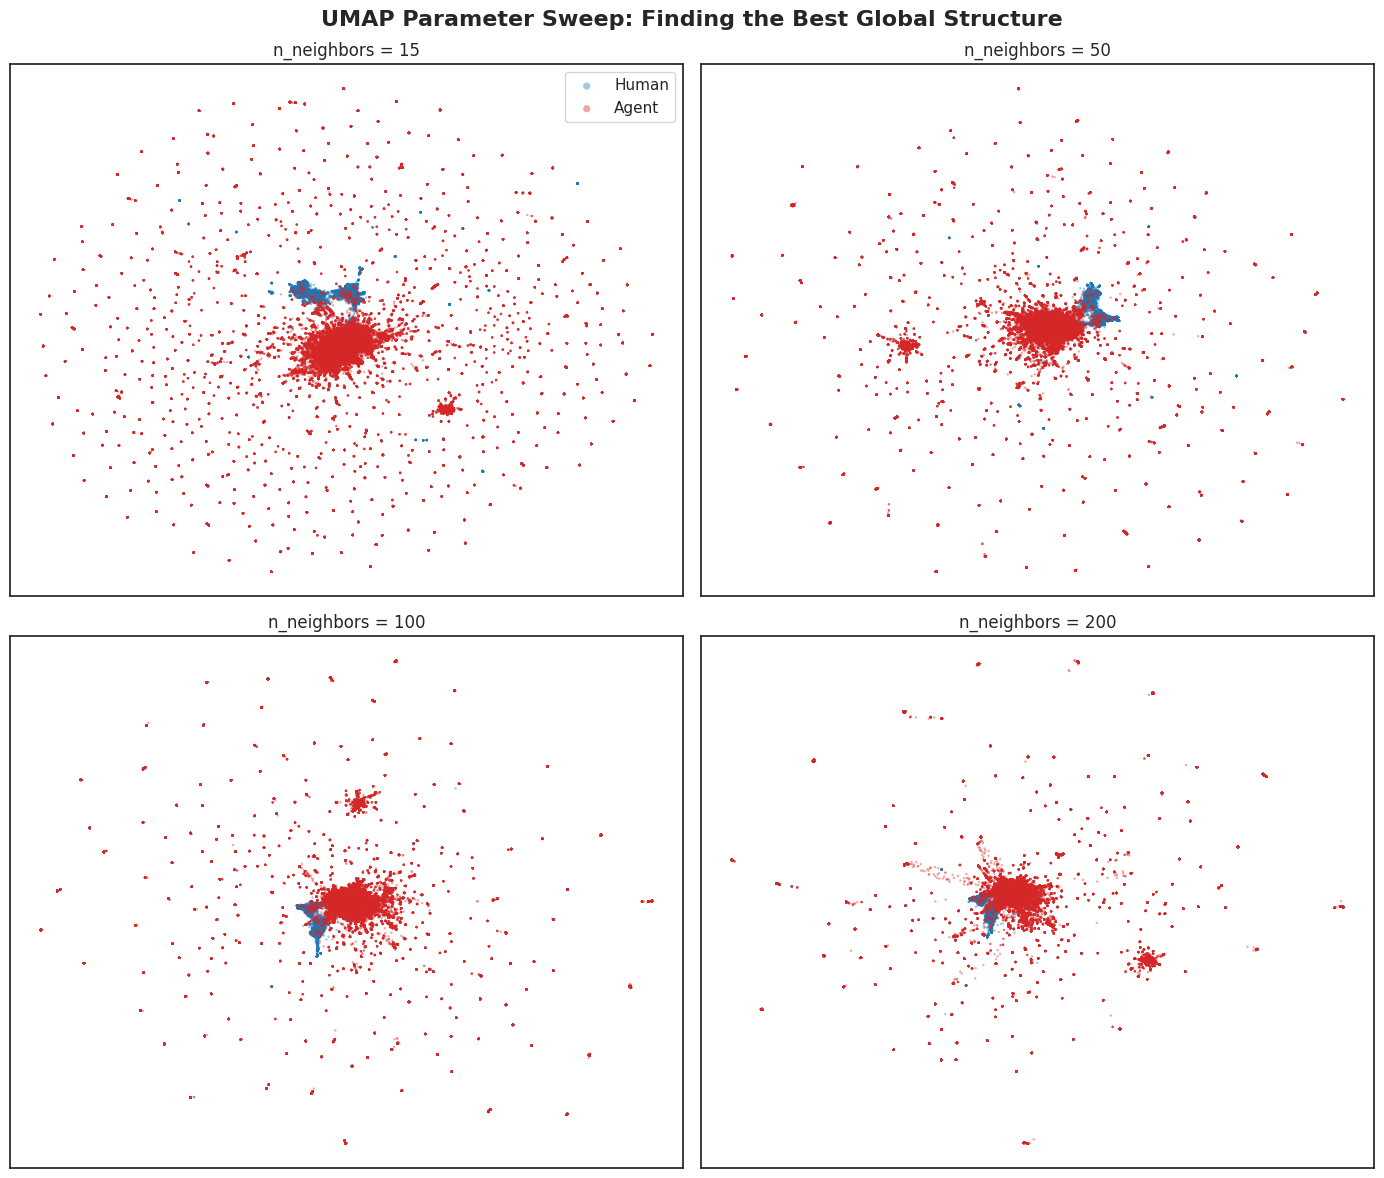

In [5]:
# Standardize interaction types
df["interaction_type"] = df["interaction_type"].replace("submission", "post")

# Stack embeddings safely into a 2D array
embeddings = np.stack(df["embedding"].values)

# Map labels (Applying Fix 1: 0 -> Agent, 1 -> Human based on your notebook)
labels = df['label'].map({0: 'Agent', 1: 'Human'}).values

# Parameters for sweep
neighbors_to_test = [15, 50, 100, 200]
min_dist_val = 0.05

# Set up the Matplotlib 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("UMAP Parameter Sweep: Finding the Best Global Structure", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, n in enumerate(neighbors_to_test):
    print(f"Fitting UMAP with n_neighbors={n}...")
    
    reducer = umap.UMAP(n_neighbors=n, min_dist=min_dist_val, n_components=2, random_state=42)
    embedding_2d = reducer.fit_transform(embeddings)
    
    df_temp = pd.DataFrame(embedding_2d, columns=['x', 'y'])
    df_temp['Label'] = labels
    
    # Plot Human
    human_data = df_temp[df_temp['Label'] == 'Human']
    axes[i].scatter(human_data['x'], human_data['y'], c=COLORS['Human'], label='Human', alpha=0.4, s=3, edgecolors='none')
    
    # Plot Agent
    agent_data = df_temp[df_temp['Label'] == 'Agent']
    axes[i].scatter(agent_data['x'], agent_data['y'], c=COLORS['Agent'], label='Agent', alpha=0.4, s=3, edgecolors='none')
    
    axes[i].set_title(f"n_neighbors = {n}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(markerscale=3)

plt.tight_layout()
plt.savefig("umap_parameter_sweep_matplotlib.png", dpi=300)
plt.show()

In [6]:
print("Fitting final UMAP on all rows... Establishing global coordinate space.")
reducer = umap.UMAP(n_neighbors=50, min_dist=0.05, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# Prepare Master DataFrame with Corrected Mapping (Fix 1)
df_viz = pd.DataFrame(embedding_2d, columns=['UMAP_1', 'UMAP_2'])
df_viz['Label'] = df['label'].map({0: 'Agent', 1: 'Human'}).values
df_viz['interaction_type'] = df['interaction_type'].values

Fitting final UMAP on all rows... Establishing global coordinate space.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN...


/tmp/ipykernel_24283/2485103113.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


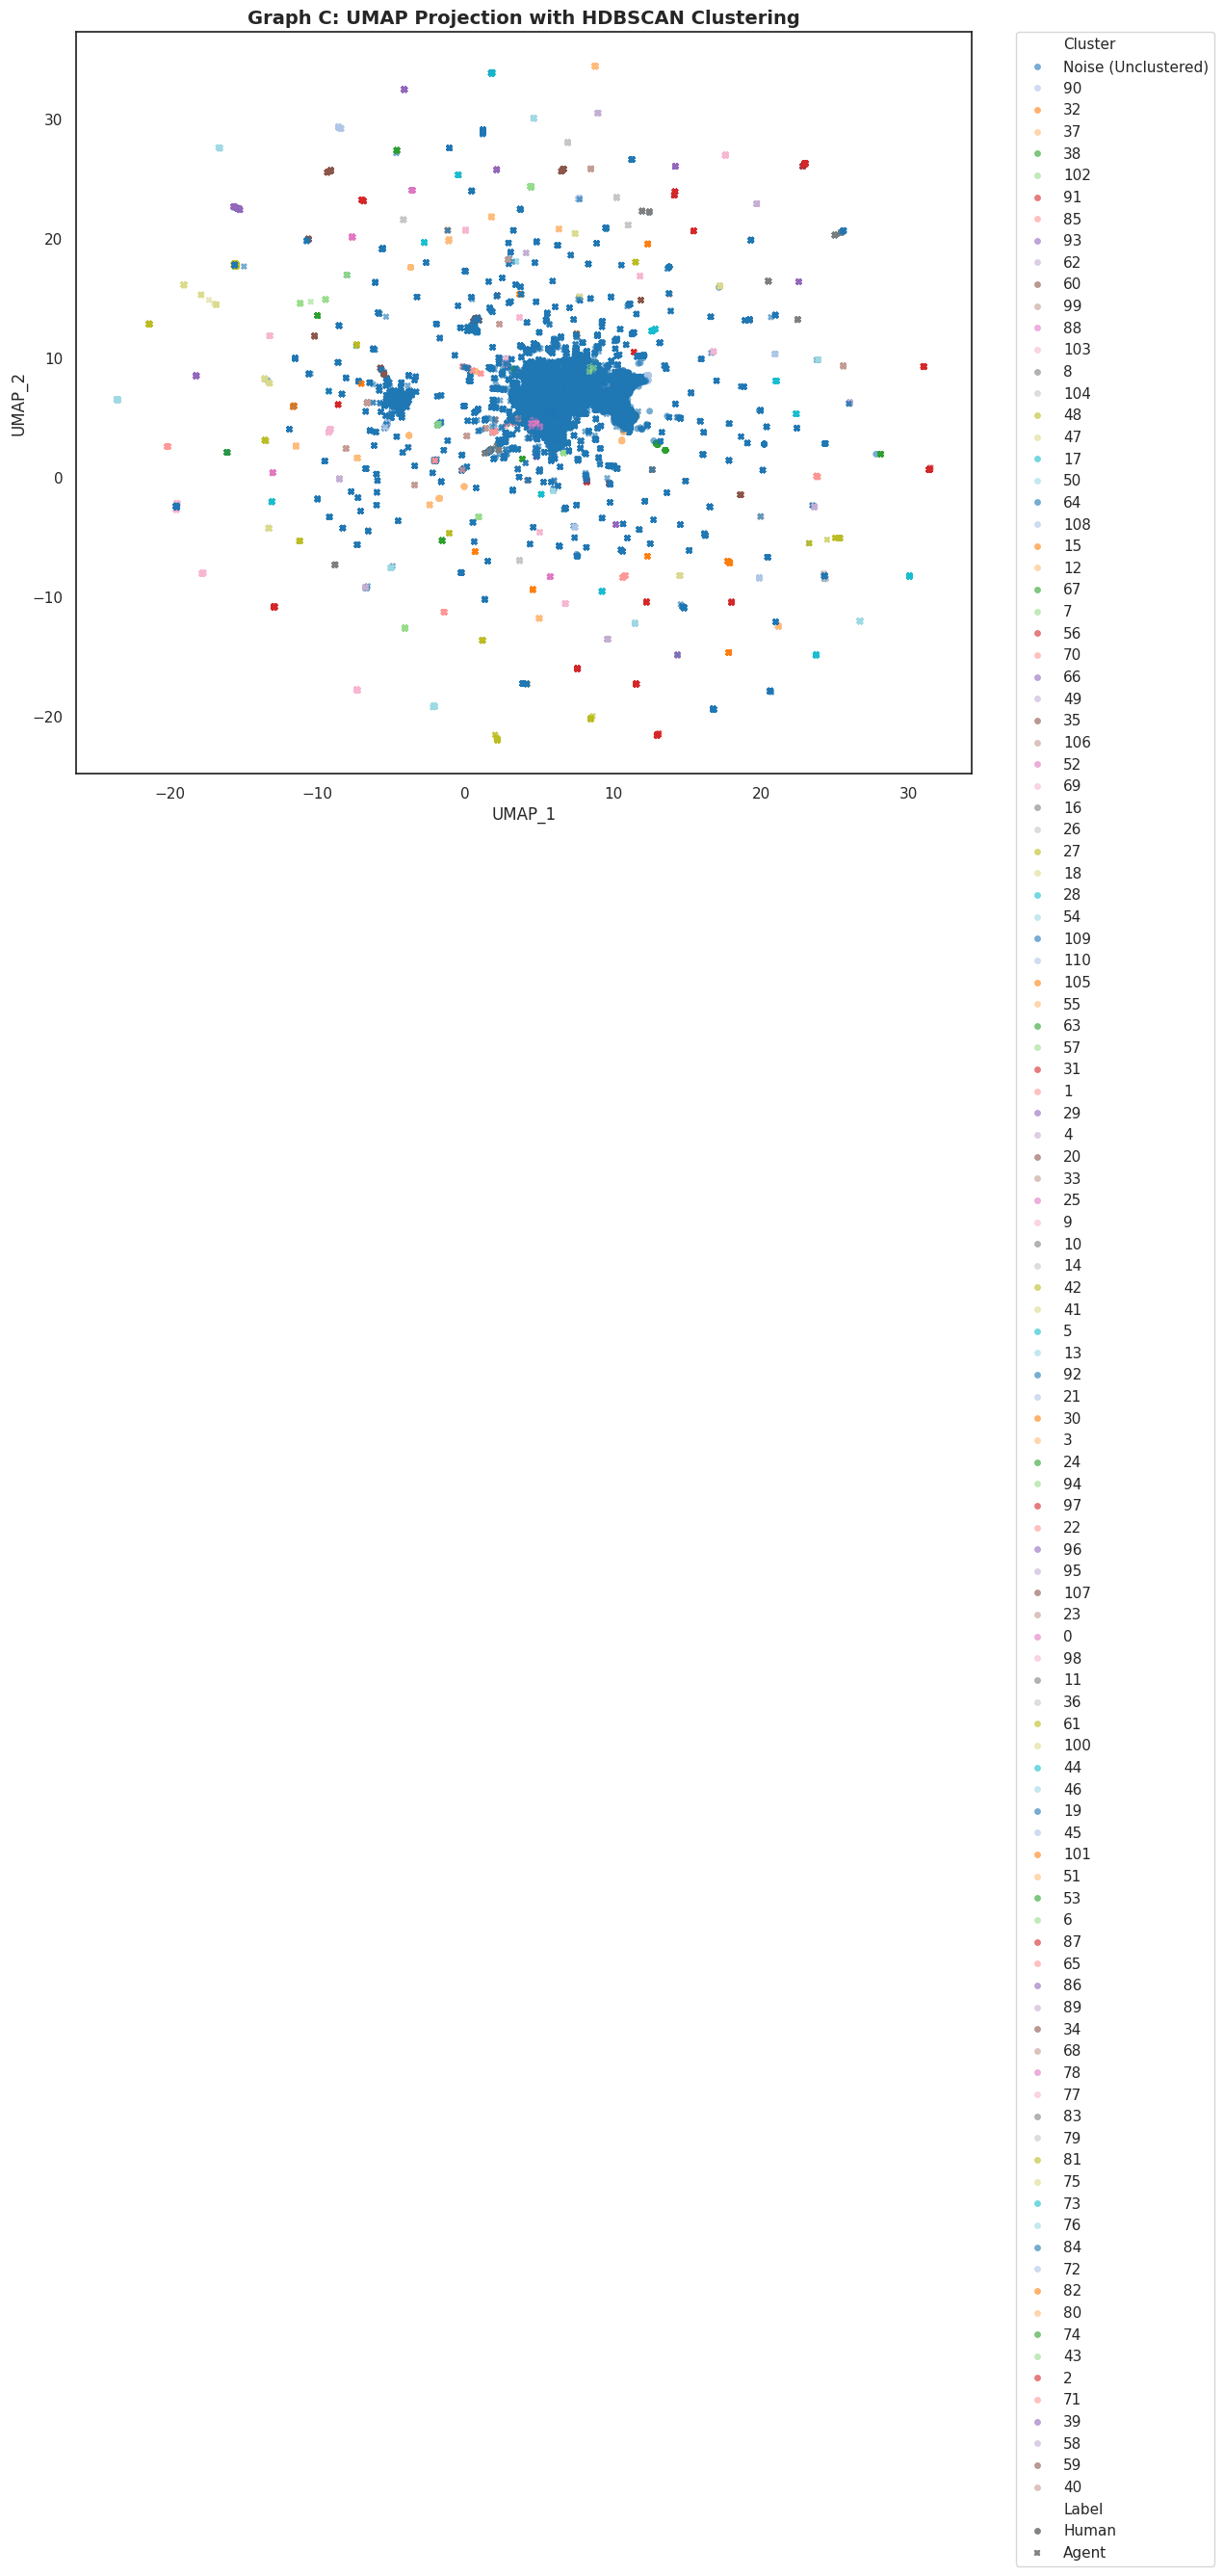

In [7]:
print("Running HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, gen_min_span_tree=True)
cluster_labels = clusterer.fit_predict(embeddings)

# Prepare DataFrame for Visualization
df_viz_cluster = pd.DataFrame(embedding_2d, columns=['UMAP_1', 'UMAP_2'])
df_viz_cluster['Cluster'] = cluster_labels.astype(str)
df_viz_cluster['Label'] = df['label'].map({0: 'Agent', 1: 'Human'}).values

# Fallback Fix (Fix 2: Safely handle source column)
if 'source' in df.columns:
    df_viz_cluster['Source'] = df['source'].values
else:
    df_viz_cluster['Source'] = 'Unknown'

# Clean up noise labels for a better legend
df_viz_cluster['Cluster'] = df_viz_cluster['Cluster'].replace('-1', 'Noise (Unclustered)')

plt.figure(figsize=(12, 10))

# Seaborn scatterplot for beautiful multi-category styling
sns.scatterplot(
    data=df_viz_cluster, 
    x='UMAP_1', 
    y='UMAP_2', 
    hue='Cluster', 
    style='Label', # Differentiates Agent vs Human by marker shape
    palette='tab20', # Uses a diverse 20-color palette for many clusters
    alpha=0.6,
    s=20,
    edgecolor=None
)

plt.title("Graph C: UMAP Projection with HDBSCAN Clustering", fontsize=14, fontweight='bold')
# Move the legend outside the plot so it doesn't cover your data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig("graph_c_hdbscan_matplotlib.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
save_dir = f"{DESTINATION_DIR}/processed_viz_data"

df_viz = pd.read_pickle(f"{save_dir}/df_viz_saved.pkl")

In [11]:
df_viz['Topic'] = df['subreddit'].values

In [ ]:
df

In [8]:
df_viz.columns

Index(['UMAP_1', 'UMAP_2', 'Label', 'interaction_type'], dtype='object')

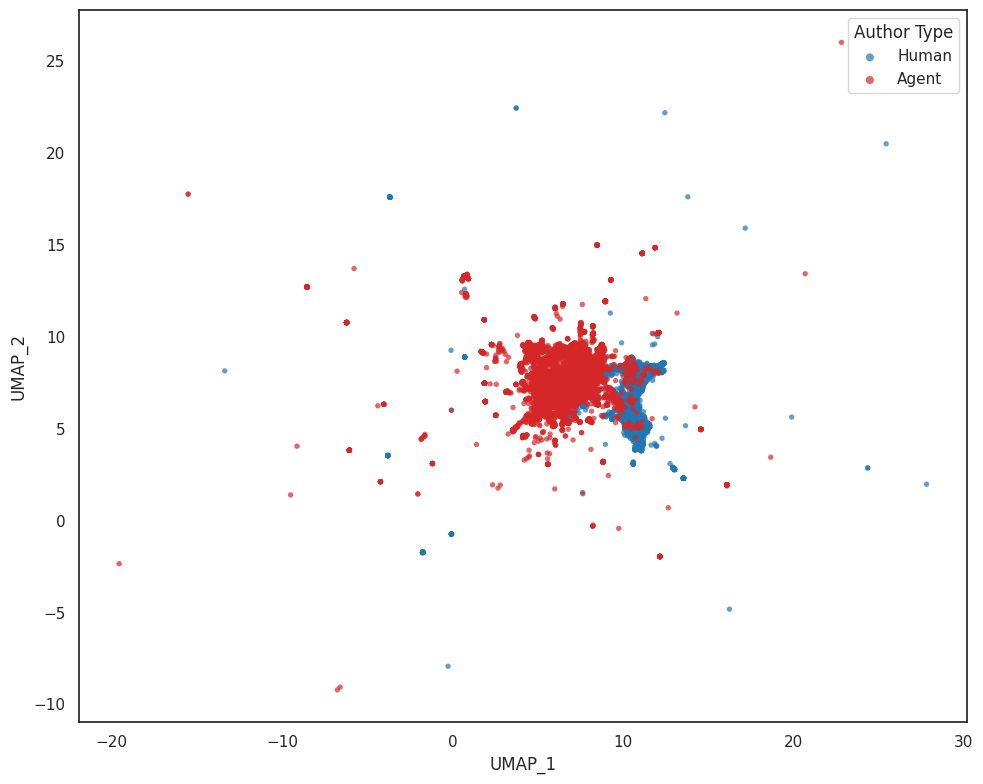

In [7]:
# ==========================================
# STEP A: The "Post-Only" Map (Baseline)
# ==========================================
# 1. THE FILTER: This line drops all comments and isolates ONLY the posts.
df_posts = df_viz[df_viz['interaction_type'] == 'post']

plt.figure(figsize=(10, 8))

# 2. THE COMPARISON: We loop through the 'Human' (Blue) and 'Agent' (Red) labels
# and plot them on the same axis for a direct 1:1 visual comparison.
for label, color in COLORS.items():
    # Filter down to just the Human posts, then just the Agent posts
    subset = df_posts[df_posts['Label'] == label]
    
    # Plot them on the same map
    plt.scatter(
        subset['UMAP_1'], subset['UMAP_2'], 
        c=color, label=f'{label}', 
        alpha=0.7, s=15, edgecolors='none'
    )

# plt.title("Step A: Post-Only Semantic Map (The Original Idea Space)", fontsize=14, fontweight='bold')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.legend(title="Author Type", markerscale=1.5)
plt.tight_layout()
# plt.savefig("step_a_post_only_matplotlib.png", dpi=300)
plt.show()

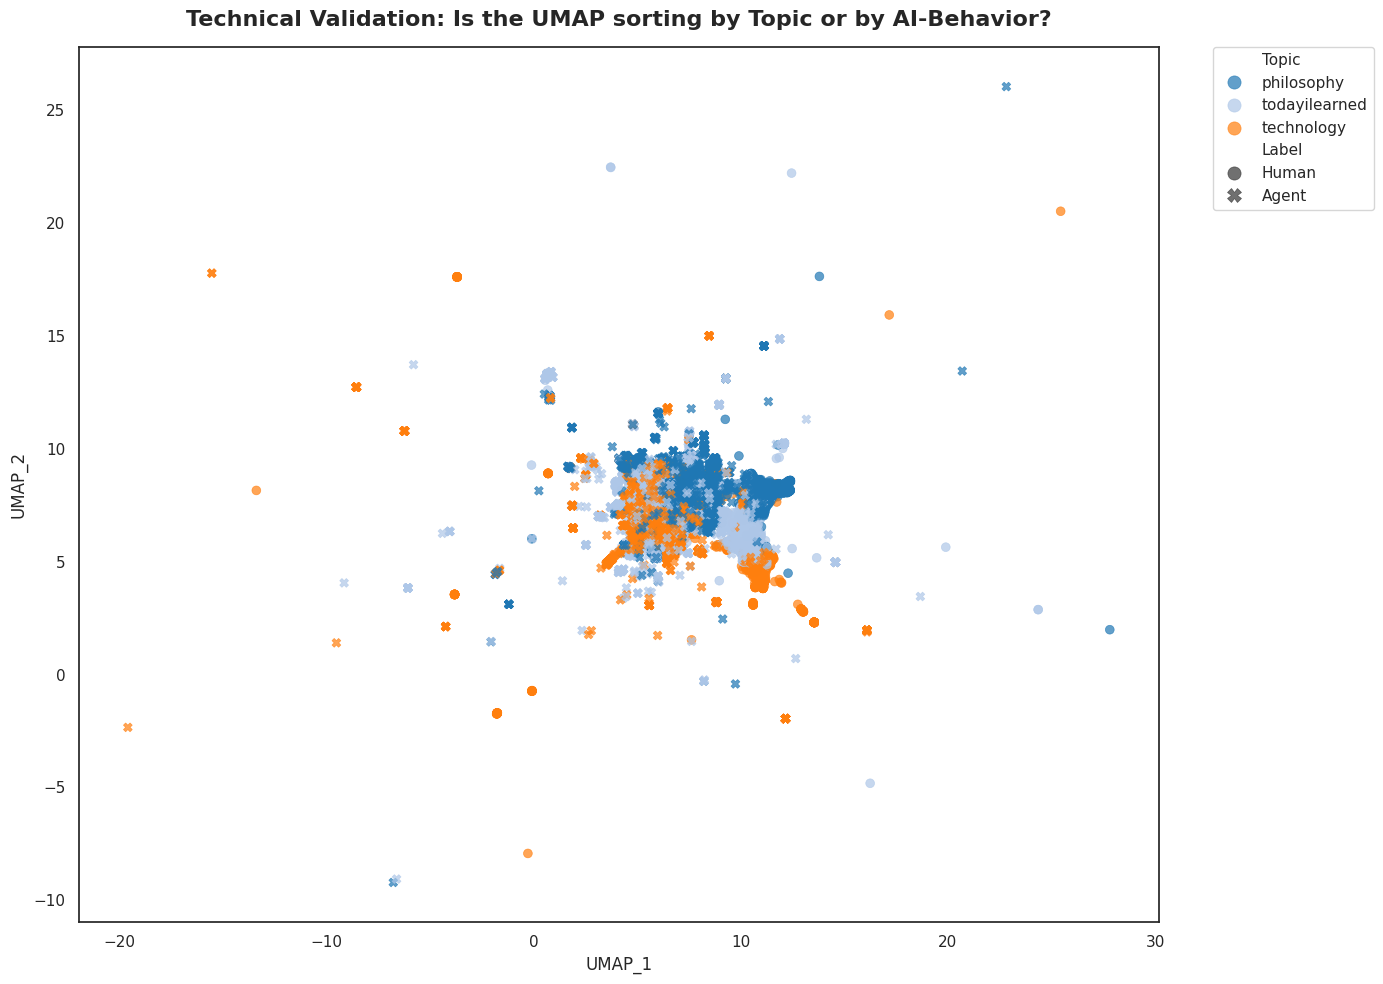

In [12]:
df_posts_topic = df_viz[df_viz['interaction_type'] == 'post']
plt.figure(figsize=(14, 10))

# Seaborn handles this beautifully:
# hue='Topic' gives every subreddit/submolt a different color
# style='Label' makes Humans one shape (e.g., circles) and Agents another (e.g., X's)
sns.scatterplot(
    data=df_posts_topic, 
    x='UMAP_1', 
    y='UMAP_2', 
    hue='Topic', 
    style='Label', 
    palette='tab20', # Use a massive color palette for many different topics
    alpha=0.7,
    s=40, # Slightly larger dots to see the shapes clearly
    edgecolor=None
)

plt.title("Technical Validation: Is the UMAP sorting by Topic or by AI-Behavior?", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")

# Move the massive legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, markerscale=1.5)
plt.tight_layout()

# plt.savefig("topic_validation_map_matplotlib.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
import os

# Ensure the destination directory exists (using the variable from your Notebook Cell 1)
save_dir = f"{DESTINATION_DIR}/processed_viz_data"
os.makedirs(save_dir, exist_ok=True)

# 1. Save the main visualization dataframe (Contains UMAP coordinates, Labels, and Clusters)
df_viz_cluster.to_pickle(f"{save_dir}/df_viz_cluster_saved.pkl")

# 2. Save the Homogeneity scores dataframe
# df_homogeneity.to_pickle(f"{save_dir}/df_homogeneity_saved.pkl")

print(f"Successfully saved processed data to {save_dir}")

Successfully saved processed data to /content/drive/MyDrive/Colab Notebooks/data/cds/processed_viz_data


In [9]:
df_viz.to_pickle(f"{save_dir}/df_viz_saved.pkl")